# 📊 Statistics from First Principles
### A hands-on notebook with worked examples and visualisations

> **Chapters**
> 1. Hypothesis Testing
> 2. P-Value
> 3. Significance Level (α)
> 4. Probability Distributions
> 5. Central Limit Theorem
> 6. Confidence Intervals
> 7. Power Analysis

---


## ⚙️ Setup — run this first

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.stats import norm, t, binom, poisson, expon, uniform
import warnings
warnings.filterwarnings('ignore')

# ── global plot style ──────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#fafafa',
    'axes.facecolor':   '#fafafa',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'axes.labelsize':   12,
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'font.family':      'DejaVu Sans',
    'lines.linewidth':  2.2,
})

BLUE   = '#2980b9'
RED    = '#c0392b'
GREEN  = '#27ae60'
PURPLE = '#8e44ad'
ORANGE = '#e67e22'
GREY   = '#95a5a6'

print("✅ All libraries loaded. Let's do statistics!")

✅ All libraries loaded. Let's do statistics!


---
## Chapter 1 — Hypothesis Testing

**The core idea:** Never look at data first and then decide what to test. Commit to a question *before* looking at evidence, then ask: *how surprised should I be by this data if nothing were going on?*

| Term | Meaning |
|------|---------|
| **H₀ (Null)** | The boring default — no effect, no difference |
| **H₁ (Alternative)** | What you suspect — a drug works, groups differ |
| **Test statistic** | A number that summarises how far the data is from H₀ |
| **Type I Error (α)** | Rejecting H₀ when it's actually true (false positive) |
| **Type II Error (β)** | Failing to reject H₀ when H₁ is true (false negative) |

### 🏥 Running Example — Drug Trial
> A pharma company claims their drug reduces blood pressure by **more than 5 mmHg**.  
> Trial: n = 50 patients, observed mean = **7.2 mmHg**, std dev = **4 mmHg**.  
> H₀: μ ≤ 5 &nbsp;&nbsp; H₁: μ > 5 &nbsp;&nbsp; (one-tailed, right-sided test)


In [2]:
# ── One-sample t-test: drug trial ─────────────────────────────
x_bar = 7.2   # observed mean reduction
mu_0  = 5.0   # null hypothesis value
s     = 4.0   # sample std deviation
n     = 50    # sample size
alpha = 0.05  # significance level

se = s / np.sqrt(n)
t_stat = (x_bar - mu_0) / se
df = n - 1
p_value = stats.t.sf(t_stat, df)          # one-tailed (right)
t_crit  = stats.t.ppf(1 - alpha, df)

print(f"Standard Error     : {se:.4f}")
print(f"t-statistic        : {t_stat:.4f}")
print(f"Degrees of freedom : {df}")
print(f"Critical value t*  : {t_crit:.4f}")
print(f"p-value (one-tail) : {p_value:.4f}")
print()
if p_value < alpha:
    print(f"✅ REJECT H₀  (p={p_value:.4f} < α={alpha})")
    print("   → Statistically significant. Evidence that drug reduces BP > 5 mmHg.")
else:
    print(f"❌ FAIL TO REJECT H₀  (p={p_value:.4f} ≥ α={alpha})")

Standard Error     : 0.5657
t-statistic        : 3.8891
Degrees of freedom : 49
Critical value t*  : 1.6766
p-value (one-tail) : 0.0002

✅ REJECT H₀  (p=0.0002 < α=0.05)
   → Statistically significant. Evidence that drug reduces BP > 5 mmHg.


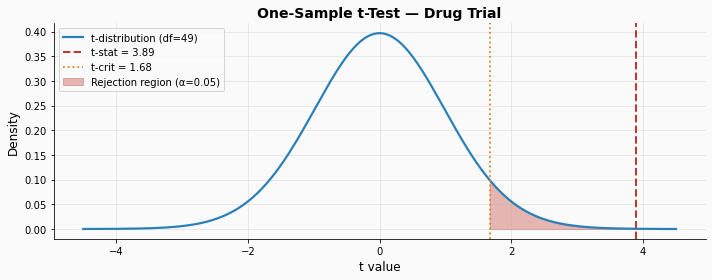

The test statistic 3.89 is beyond the critical value 1.68 → Reject H₀


In [3]:
# ── Visualise the t-distribution with rejection region ────────
x = np.linspace(-4.5, 4.5, 400)
y = stats.t.pdf(x, df)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, y, color=BLUE, label=f't-distribution (df={df})')

# shade rejection region
x_rej = np.linspace(t_crit, 4.5, 200)
ax.fill_between(x_rej, stats.t.pdf(x_rej, df), alpha=0.35, color=RED, label=f'Rejection region (α={alpha})')

# mark test statistic
ax.axvline(t_stat, color=RED, linestyle='--', linewidth=2, label=f't-stat = {t_stat:.2f}')
ax.axvline(t_crit, color=ORANGE, linestyle=':', linewidth=1.8, label=f't-crit = {t_crit:.2f}')

ax.set_title('One-Sample t-Test — Drug Trial')
ax.set_xlabel('t value')
ax.set_ylabel('Density')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
print(f"The test statistic {t_stat:.2f} is beyond the critical value {t_crit:.2f} → Reject H₀")

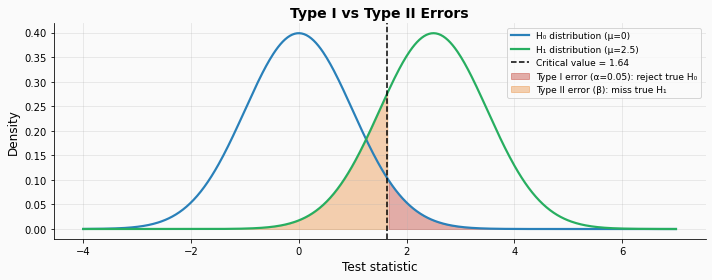

In [4]:
# ── Type I & Type II error visualisation ──────────────────────
mu_null = 0;  mu_alt = 2.5;  sigma = 1
x = np.linspace(-4, 7, 500)
y_null = norm.pdf(x, mu_null, sigma)
y_alt  = norm.pdf(x, mu_alt,  sigma)
crit = norm.ppf(1 - 0.05, mu_null, sigma)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, y_null, color=BLUE,  label='H₀ distribution (μ=0)')
ax.plot(x, y_alt,  color=GREEN, label='H₁ distribution (μ=2.5)')

# Type I error
x_t1 = x[x >= crit]
ax.fill_between(x_t1, norm.pdf(x_t1, mu_null, sigma), alpha=0.4, color=RED,
                label=f'Type I error (α=0.05): reject true H₀')

# Type II error
x_t2 = x[x < crit]
ax.fill_between(x_t2, norm.pdf(x_t2, mu_alt, sigma), alpha=0.35, color=ORANGE,
                label='Type II error (β): miss true H₁')

ax.axvline(crit, color='black', linestyle='--', linewidth=1.5, label=f'Critical value = {crit:.2f}')
ax.set_title('Type I vs Type II Errors')
ax.set_xlabel('Test statistic'); ax.set_ylabel('Density')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

---
## Chapter 2 — The P-Value

The p-value is the **most misunderstood** number in science.

**What it IS:**
> The probability of observing data *at least as extreme* as yours, **assuming H₀ is true**.

**What it is NOT:**
- ❌ The probability that H₀ is true
- ❌ The probability you are wrong
- ❌ The probability the result happened by chance

### 🪙 Coin Flip Example
You suspect a coin is biased toward heads.  
You flip it 20 times and get **16 heads**.  
H₀: p = 0.5 (fair coin) &nbsp; H₁: p > 0.5


In [5]:
# ── Exact binomial p-value: coin flip ─────────────────────────
n_flips   = 20
k_heads   = 16
p_fair    = 0.5

# P(X >= 16) under H₀
p_value_coin = binom.sf(k_heads - 1, n_flips, p_fair)   # sf = 1 - CDF

print(f"Flips: {n_flips}  |  Heads observed: {k_heads}  |  Expected: {n_flips*p_fair:.0f}")
print(f"P(X ≥ {k_heads} | fair coin) = {p_value_coin:.5f}")
print()
print("Interpretation: If the coin were truly fair, we'd see 16+ heads")
print(f"in only {p_value_coin*100:.2f}% of experiments. That's pretty rare!")
if p_value_coin < 0.05:
    print("→ Reject H₀ at α=0.05: evidence of a biased coin.")

Flips: 20  |  Heads observed: 16  |  Expected: 10
P(X ≥ 16 | fair coin) = 0.00591

Interpretation: If the coin were truly fair, we'd see 16+ heads
in only 0.59% of experiments. That's pretty rare!
→ Reject H₀ at α=0.05: evidence of a biased coin.


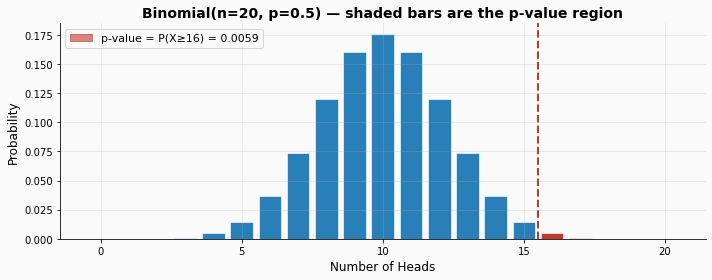

In [6]:
# ── Visualise the binomial p-value ────────────────────────────
k = np.arange(0, n_flips + 1)
pmf = binom.pmf(k, n_flips, p_fair)

colors = [RED if ki >= k_heads else BLUE for ki in k]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(k, pmf, color=colors, edgecolor='white', linewidth=0.6)
ax.axvline(k_heads - 0.5, color=RED, linestyle='--', linewidth=2,
           label=f'Observed k={k_heads}')
ax.set_xlabel('Number of Heads'); ax.set_ylabel('Probability')
ax.set_title(f'Binomial(n={n_flips}, p=0.5) — shaded bars are the p-value region')
ax.legend(fontsize=10)

# annotate p-value
p_patch = mpatches.Patch(color=RED, alpha=0.6,
    label=f'p-value = P(X≥{k_heads}) = {p_value_coin:.4f}')
ax.legend(handles=[p_patch], fontsize=11)
plt.tight_layout(); plt.show()

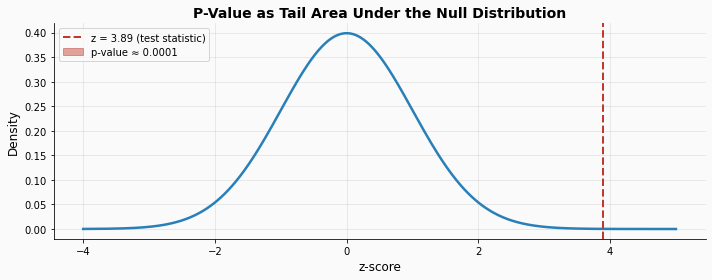

The shaded region = probability of seeing data this extreme if H₀ were true.


In [7]:
# ── p-value under the normal curve (continuous case) ──────────
# Reusing the drug trial t-stat converted to z for illustration
z_stat = t_stat   # approximately z for large n

x = np.linspace(-4, 5, 500)
y = norm.pdf(x)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, y, color=BLUE, linewidth=2.5)

x_shade = x[x >= z_stat]
ax.fill_between(x_shade, norm.pdf(x_shade), color=RED, alpha=0.45,
                label=f'p-value ≈ {norm.sf(z_stat):.4f}')
ax.axvline(z_stat, color=RED, linestyle='--', linewidth=2,
           label=f'z = {z_stat:.2f} (test statistic)')

ax.set_title('P-Value as Tail Area Under the Null Distribution')
ax.set_xlabel('z-score'); ax.set_ylabel('Density')
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()
print("The shaded region = probability of seeing data this extreme if H₀ were true.")

---
## Chapter 3 — Significance Level (α)

α is the threshold you set **before looking at data** — your tolerance for false positives.

| Field | Typical α | Reason |
|-------|-----------|--------|
| Clinical trials | 0.01 | Lives at stake |
| A/B testing (tech) | 0.05–0.10 | Speed matters |
| Physics (Higgs Boson) | 0.0000003 | Extraordinary claims |
| Exploratory research | 0.10 | Just finding signals |

α = 0.05 is convention, not magic. It means: *in a world where H₀ is always true, I will incorrectly reject it 5% of the time.*


In [8]:
# ── Critical values for common α levels ───────────────────────
print("Two-tailed critical values (z*):")
print("-" * 35)
for cl in [0.90, 0.95, 0.99, 0.999]:
    alpha_level = 1 - cl
    z_star = norm.ppf(1 - alpha_level/2)
    print(f"  {cl*100:.1f}% CI  |  α = {alpha_level:.3f}  |  z* = ±{z_star:.4f}")

Two-tailed critical values (z*):
-----------------------------------
  90.0% CI  |  α = 0.100  |  z* = ±1.6449
  95.0% CI  |  α = 0.050  |  z* = ±1.9600
  99.0% CI  |  α = 0.010  |  z* = ±2.5758
  99.9% CI  |  α = 0.001  |  z* = ±3.2905


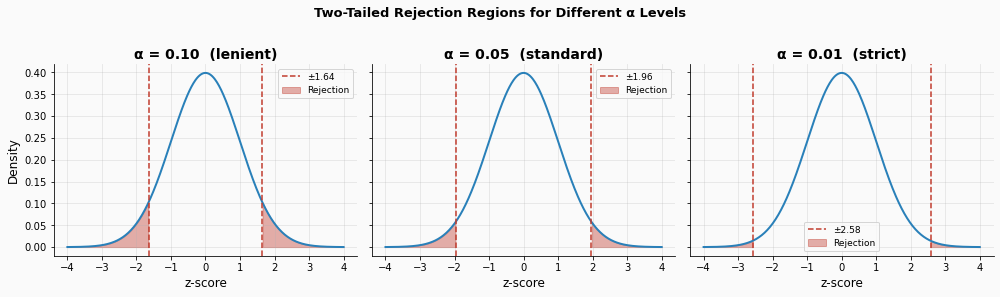

In [9]:
# ── Visualise rejection regions for different α ───────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
alphas = [0.10, 0.05, 0.01]
titles = ['α = 0.10  (lenient)', 'α = 0.05  (standard)', 'α = 0.01  (strict)']

x = np.linspace(-4, 4, 400)
for ax, a, title in zip(axes, alphas, titles):
    z_c = norm.ppf(1 - a/2)
    y = norm.pdf(x)
    ax.plot(x, y, color=BLUE, linewidth=2)
    # shade rejection regions
    for mask, lbl in [(x <= -z_c, 'Rejection'), (x >= z_c, None)]:
        ax.fill_between(x, y, where=mask, alpha=0.4, color=RED,
                        label=lbl if lbl else '')
    ax.axvline(-z_c, color=RED, linestyle='--', linewidth=1.5)
    ax.axvline( z_c, color=RED, linestyle='--', linewidth=1.5,
                label=f'±{z_c:.2f}')
    ax.set_title(title); ax.set_xlabel('z-score')
    if ax == axes[0]: ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Two-Tailed Rejection Regions for Different α Levels', y=1.02,
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Chapter 4 — Probability Distributions

A distribution is the *shape of randomness* for a given phenomenon. Different processes produce different shapes.


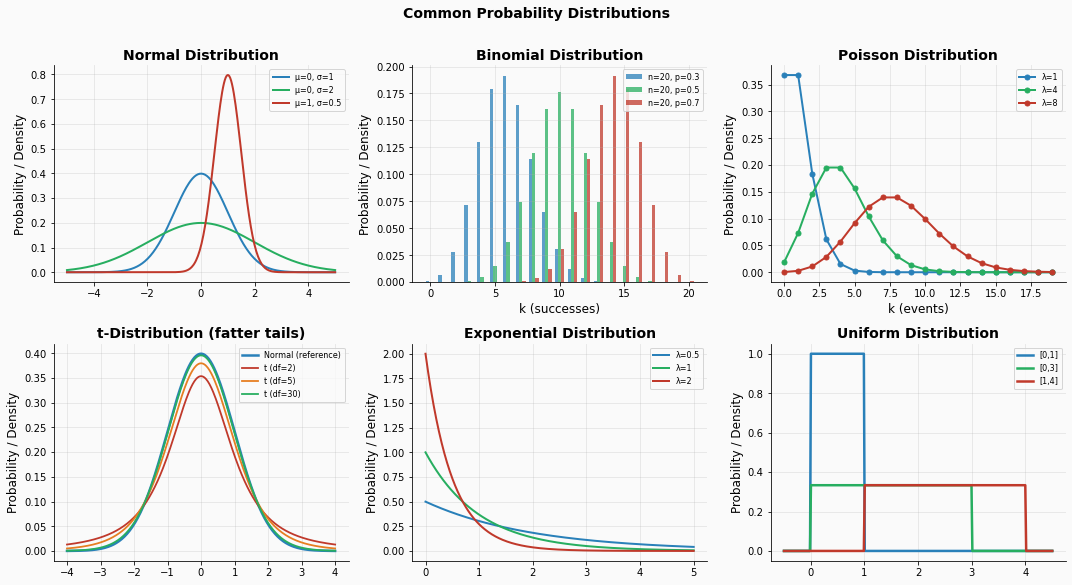

In [12]:
# ── Gallery of common distributions ──────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# 1. Normal
x = np.linspace(-5, 5, 300)
for mu, s, c in [(0, 1, BLUE), (0, 2, GREEN), (1, 0.5, RED)]:
    axes[0].plot(x, norm.pdf(x, mu, s), color=c, linewidth=2,
                 label=f'μ={mu}, σ={s}')
axes[0].set_title('Normal Distribution'); axes[0].legend(fontsize=8)

# 2. Binomial
k = np.arange(0, 21)
offsets = [-0.25, 0, 0.25]
for i, (n_b, p_b, c) in enumerate([(20, 0.3, BLUE), (20, 0.5, GREEN), (20, 0.7, RED)]):
    axes[1].bar(
        k + offsets[i],
        binom.pmf(k, n_b, p_b),
        width=0.25,
        color=c,
        alpha=0.75,
        label=f'n={n_b}, p={p_b}'
    )
axes[1].set_title('Binomial Distribution')
axes[1].legend(fontsize=8)
axes[1].set_xlabel('k (successes)')

# 3. Poisson
k = np.arange(0, 20)
for lam, c in [(1, BLUE), (4, GREEN), (8, RED)]:
    axes[2].plot(k, poisson.pmf(k, lam), 'o-', color=c, linewidth=2, markersize=5,
                 label=f'λ={lam}')
axes[2].set_title('Poisson Distribution'); axes[2].legend(fontsize=8)
axes[2].set_xlabel('k (events)')

# 4. t-distribution vs Normal
x = np.linspace(-4, 4, 300)
axes[3].plot(x, norm.pdf(x), color=BLUE, linewidth=2.5, label='Normal (reference)')
for df_t, c in [(2, RED), (5, ORANGE), (30, GREEN)]:
    axes[3].plot(x, t.pdf(x, df_t), color=c, linewidth=1.8, label=f't (df={df_t})')
axes[3].set_title('t-Distribution (fatter tails)'); axes[3].legend(fontsize=8)

# 5. Exponential
x = np.linspace(0, 5, 300)
for lam_e, c in [(0.5, BLUE), (1, GREEN), (2, RED)]:
    axes[4].plot(x, expon.pdf(x, scale=1/lam_e), color=c, linewidth=2,
                 label=f'λ={lam_e}')
axes[4].set_title('Exponential Distribution'); axes[4].legend(fontsize=8)

# 6. Uniform
x = np.linspace(-0.5, 4.5, 300)
for a_u, b_u, c in [(0,1,BLUE),(0,3,GREEN),(1,4,RED)]:
    axes[5].plot(x, uniform.pdf(x, a_u, b_u-a_u), color=c, linewidth=2.5,
                 label=f'[{a_u},{b_u}]')
axes[5].set_title('Uniform Distribution'); axes[5].legend(fontsize=8)

for ax in axes: ax.set_ylabel('Probability / Density')
plt.suptitle('Common Probability Distributions', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

In [13]:
# ── Distribution summary table ────────────────────────────────
import pandas as pd

data = {
    'Distribution': ['Normal', 'Binomial', 'Poisson', 't', 'Exponential', 'Uniform'],
    'Parameters':   ['μ, σ', 'n, p', 'λ', 'df', 'λ', 'a, b'],
    'Support':      ['(−∞, ∞)', '{0,…,n}', '{0,1,2,…}', '(−∞, ∞)', '[0, ∞)', '[a, b]'],
    'Mean':         ['μ', 'np', 'λ', '0 (df>1)', '1/λ', '(a+b)/2'],
    'Variance':     ['σ²', 'np(1−p)', 'λ', 'df/(df−2)', '1/λ²', '(b−a)²/12'],
    'Classic Use':  [
        'Heights, errors, test scores',
        'Count of successes in n trials',
        'Events per unit time/area',
        'Small samples, unknown σ',
        'Time between events',
        'Random number generation'
    ]
}
df_table = pd.DataFrame(data)
print(df_table.to_string(index=False))

Distribution Parameters   Support     Mean  Variance                    Classic Use
      Normal       μ, σ   (−∞, ∞)        μ        σ²   Heights, errors, test scores
    Binomial       n, p   {0,…,n}       np   np(1−p) Count of successes in n trials
     Poisson          λ {0,1,2,…}        λ         λ      Events per unit time/area
           t         df   (−∞, ∞) 0 (df>1) df/(df−2)       Small samples, unknown σ
 Exponential          λ    [0, ∞)      1/λ      1/λ²            Time between events
     Uniform       a, b    [a, b]  (a+b)/2 (b−a)²/12       Random number generation


---
## Chapter 5 — Central Limit Theorem (CLT)

> **If you draw samples of size n from ANY population with mean μ and finite variance σ², then as n → ∞, the distribution of sample means approaches Normal(μ, σ²/n).**

This is why statistics works. It doesn't matter if the underlying data is skewed, bimodal, or uniform — average enough observations and the sampling distribution becomes bell-shaped.

$$\bar{x} \sim N\left(\mu,\ \frac{\sigma^2}{n}\right) \quad \text{as } n \to \infty$$

The standard deviation of the sampling distribution is called the **Standard Error**: $SE = \sigma / \sqrt{n}$


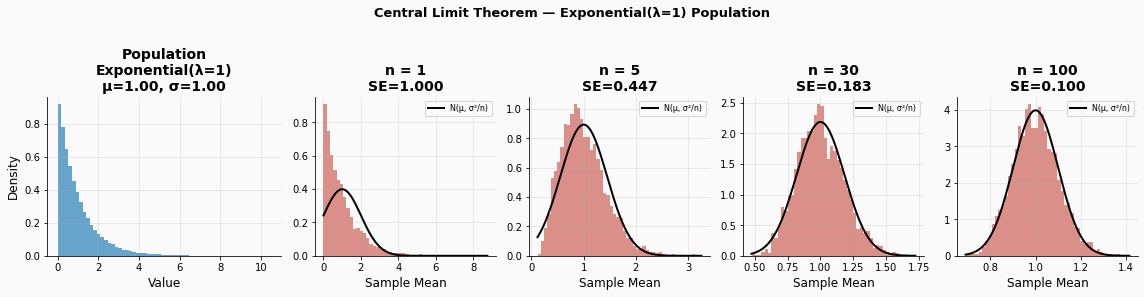

In [14]:
# ── CLT simulation ────────────────────────────────────────────
np.random.seed(42)

def simulate_clt(dist_name, pop_generator, true_mean, true_sd,
                 sample_sizes=(1, 5, 30, 100), n_sim=3000):
    
    fig, axes = plt.subplots(1, len(sample_sizes) + 1,
                             figsize=(16, 4), gridspec_kw={'width_ratios':[1.3]+[1]*len(sample_sizes)})
    
    # Population
    pop = pop_generator(50_000)
    axes[0].hist(pop, bins=60, density=True, color=BLUE, alpha=0.7, edgecolor='none')
    axes[0].set_title(f'Population\n{dist_name}\nμ={true_mean:.2f}, σ={true_sd:.2f}')
    axes[0].set_xlabel('Value'); axes[0].set_ylabel('Density')
    
    for ax, n_s in zip(axes[1:], sample_sizes):
        sample_means = [pop_generator(n_s).mean() for _ in range(n_sim)]
        ax.hist(sample_means, bins=50, density=True, color=RED, alpha=0.55, edgecolor='none')
        
        # overlay theoretical normal
        x_range = np.linspace(np.min(sample_means), np.max(sample_means), 200)
        se_theory = true_sd / np.sqrt(n_s)
        ax.plot(x_range, norm.pdf(x_range, true_mean, se_theory),
                color='black', linewidth=2, label='N(μ, σ²/n)')
        
        ax.set_title(f'n = {n_s}\nSE={se_theory:.3f}')
        ax.set_xlabel('Sample Mean')
        ax.legend(fontsize=8)
    
    plt.suptitle(f'Central Limit Theorem — {dist_name} Population', 
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout(); plt.show()

# 1. Exponential (heavily right-skewed)
simulate_clt(
    'Exponential(λ=1)',
    lambda n: np.random.exponential(scale=1, size=n),
    true_mean=1.0, true_sd=1.0
)

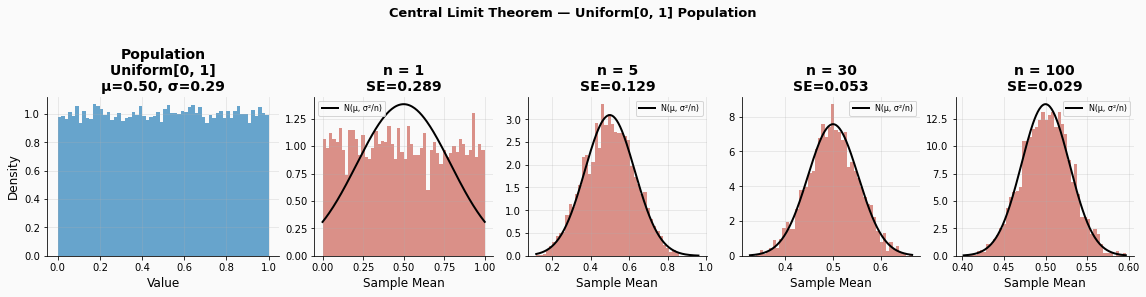

In [15]:
# 2. Uniform (completely flat)
simulate_clt(
    'Uniform[0, 1]',
    lambda n: np.random.uniform(0, 1, size=n),
    true_mean=0.5, true_sd=np.sqrt(1/12)
)

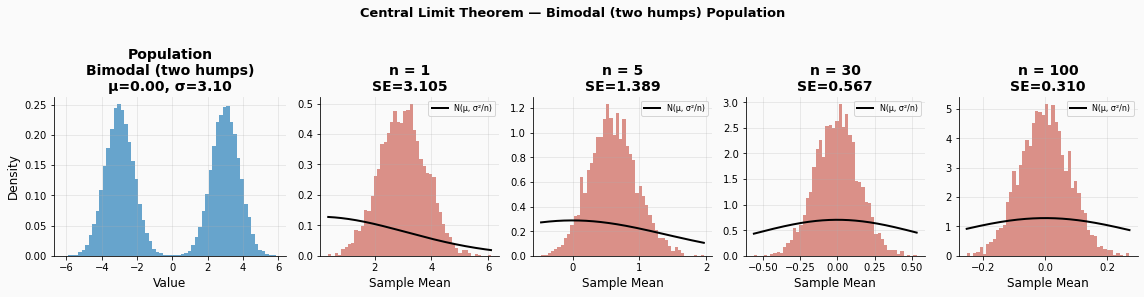

In [16]:
# 3. Bimodal (two humps)
def bimodal(n):
    half = n // 2
    return np.concatenate([np.random.normal(-3, 0.8, half),
                           np.random.normal( 3, 0.8, n - half)])

simulate_clt(
    'Bimodal (two humps)',
    bimodal,
    true_mean=0.0, true_sd=np.sqrt(0.64 + 9)
)

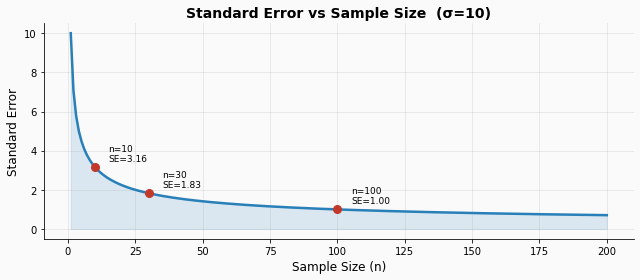

Key insight: doubling n reduces SE by √2 ≈ 1.41x, not 2x.
You need 4× the data to halve the standard error.


In [17]:
# ── SE shrinks with sample size ───────────────────────────────
sigma = 10
sample_sizes = np.arange(1, 201)
se_curve = sigma / np.sqrt(sample_sizes)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sample_sizes, se_curve, color=BLUE, linewidth=2.5)
ax.fill_between(sample_sizes, se_curve, alpha=0.15, color=BLUE)
for n_mark in [10, 30, 100]:
    se_m = sigma / np.sqrt(n_mark)
    ax.plot(n_mark, se_m, 'o', color=RED, markersize=8, zorder=5)
    ax.annotate(f'n={n_mark}\nSE={se_m:.2f}', (n_mark, se_m),
                xytext=(n_mark+5, se_m+0.3), fontsize=9)

ax.set_title(f'Standard Error vs Sample Size  (σ={sigma})')
ax.set_xlabel('Sample Size (n)'); ax.set_ylabel('Standard Error')
plt.tight_layout(); plt.show()
print("Key insight: doubling n reduces SE by √2 ≈ 1.41x, not 2x.")
print("You need 4× the data to halve the standard error.")

---
## Chapter 6 — Confidence Intervals

A point estimate (x̄ = 7.2) is useful but gives no sense of uncertainty. A **confidence interval** provides a range that, by construction, captures the true parameter a specified fraction of the time.

$$CI = \bar{x} \pm z^* \cdot \frac{s}{\sqrt{n}}$$

| Confidence Level | z* |
|------------------|----|
| 90% | 1.645 |
| 95% | 1.960 |
| 99% | 2.576 |

> ⚠️ **The correct interpretation:** *If we repeated this study many times, 95% of the resulting intervals would contain the true μ.* The 95% refers to the procedure, not this specific interval.


In [18]:
# ── Confidence interval for drug trial ───────────────────────
x_bar = 7.2; s = 4.0; n = 50

for cl in [0.90, 0.95, 0.99]:
    alpha_ci = 1 - cl
    z_star = norm.ppf(1 - alpha_ci/2)
    se = s / np.sqrt(n)
    lo = x_bar - z_star * se
    hi = x_bar + z_star * se
    print(f"{cl*100:.0f}% CI: ({lo:.3f},  {hi:.3f})   width={hi-lo:.3f}   z*={z_star:.3f}")

90% CI: (6.270,  8.130)   width=1.861   z*=1.645
95% CI: (6.091,  8.309)   width=2.217   z*=1.960
99% CI: (5.743,  8.657)   width=2.914   z*=2.576


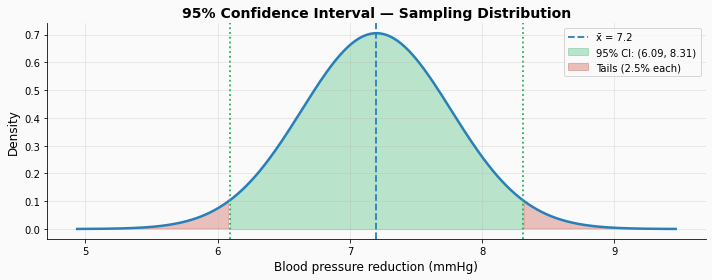

In [19]:
# ── Visualise one CI on the sampling distribution ─────────────
alpha_ci = 0.05; z_star = norm.ppf(0.975)
se = s / np.sqrt(n)
lo = x_bar - z_star * se
hi = x_bar + z_star * se

x = np.linspace(x_bar - 4*se, x_bar + 4*se, 400)
y = norm.pdf(x, x_bar, se)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, y, color=BLUE, linewidth=2.5)

# shade CI region (green) and tails (red)
ax.fill_between(x, y, where=(x >= lo) & (x <= hi), color=GREEN, alpha=0.3,
                label=f'95% CI: ({lo:.2f}, {hi:.2f})')
ax.fill_between(x, y, where=(x < lo) | (x > hi), color=RED, alpha=0.3,
                label='Tails (2.5% each)')
ax.axvline(x_bar, color=BLUE, linestyle='--', linewidth=1.8, label=f'x̄ = {x_bar}')
ax.axvline(lo, color=GREEN, linestyle=':', linewidth=1.8)
ax.axvline(hi, color=GREEN, linestyle=':', linewidth=1.8)

ax.set_title('95% Confidence Interval — Sampling Distribution')
ax.set_xlabel('Blood pressure reduction (mmHg)'); ax.set_ylabel('Density')
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

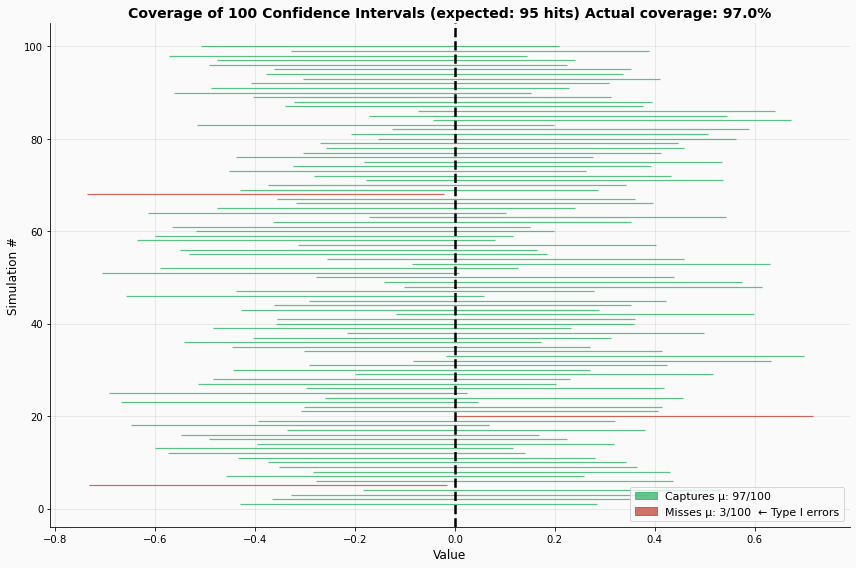

In [25]:
# ── Coverage simulation: 100 confidence intervals ─────────────
np.random.seed(7)
true_mu = 0; sigma = 1; n_sim = 100; n_size = 30
alpha_ci = 0.05; z_star = norm.ppf(1 - alpha_ci/2)

intervals = []
for _ in range(n_sim):
    sample = np.random.normal(true_mu, sigma, n_size)
    xb = sample.mean(); se_s = sigma / np.sqrt(n_size)
    intervals.append((xb - z_star*se_s, xb + z_star*se_s))

hits   = sum(lo <= true_mu <= hi for lo, hi in intervals)
misses = n_sim - hits

fig, ax = plt.subplots(figsize=(12, 8))
for i, (lo, hi) in enumerate(intervals):
    covers = lo <= true_mu <= hi
    color  = GREEN if covers else RED
    ax.hlines(i+1, lo, hi, color=color, linewidth=1.2, alpha=0.75)

ax.axvline(true_mu, color='black', linewidth=2.5, linestyle='--',
           label=f'True μ = {true_mu}')

green_p = mpatches.Patch(color=GREEN, alpha=0.7, label=f'Captures μ: {hits}/{n_sim}')
red_p   = mpatches.Patch(color=RED,   alpha=0.7, label=f'Misses μ: {misses}/{n_sim}  ← Type I errors')
ax.legend(handles=[green_p, red_p], fontsize=11, loc='lower right')
ax.set_xlabel('Value'); ax.set_ylabel('Simulation #')
ax.set_title(f'Coverage of {n_sim} Confidence Intervals (expected: 95 hits) Actual coverage: {hits/n_sim*100:.1f}%')
plt.tight_layout(); plt.show()

---
## Chapter 7 — Power Analysis

**Statistical power = 1 − β** = probability of detecting a real effect when it truly exists.

Low power → you miss real effects. Publishing underpowered results → inflated effect estimates.

### The Four Levers
| Factor | Increase → Power |
|--------|-----------------|
| Effect size *d* | ↑ Larger difference is easier to detect |
| Sample size *n* | ↑ More data, smaller SE |
| α | ↑ More lenient threshold (but more Type I errors) |
| σ (noise) | ↓ Noisier data obscures the signal |

### Cohen's d (effect size)
$$d = \frac{|\mu_1 - \mu_2|}{\sigma_{pooled}}$$

| d | Interpretation |
|---|---------------|
| 0.2 | Small |
| 0.5 | Medium |
| 0.8 | Large |


In [21]:
# ── Power calculation for two-sample t-test ───────────────────
from scipy.stats import norm as z_dist

def compute_power(d, n, alpha=0.05):
    """Two-sided power for two-sample t-test (equal group sizes)."""
    se = np.sqrt(2 / n)
    z_alpha = z_dist.ppf(1 - alpha/2)
    z_beta = d / se - z_alpha
    return z_dist.cdf(z_beta)

def required_n(d, power=0.80, alpha=0.05):
    """Minimum n per group for desired power."""
    z_alpha = z_dist.ppf(1 - alpha/2)
    z_beta  = z_dist.ppf(power)
    return int(np.ceil(2 * ((z_alpha + z_beta) / d) ** 2))

# Drug trial: two groups, Cohen's d = 0.55
d_example = 0.55; n_example = 50; alpha_ex = 0.05

pwr = compute_power(d_example, n_example, alpha_ex)
n_req = required_n(d_example)

print(f"Effect size (d)   : {d_example}")
print(f"Sample size (n)   : {n_example} per group")
print(f"α                 : {alpha_ex}")
print(f"Statistical Power : {pwr:.3f}  ({pwr*100:.1f}%)")
print(f"β (Type II error) : {1-pwr:.3f}  ({(1-pwr)*100:.1f}%)")
print()
print(f"→ Need at least {n_req} subjects per group for 80% power")

Effect size (d)   : 0.55
Sample size (n)   : 50 per group
α                 : 0.05
Statistical Power : 0.785  (78.5%)
β (Type II error) : 0.215  (21.5%)

→ Need at least 52 subjects per group for 80% power


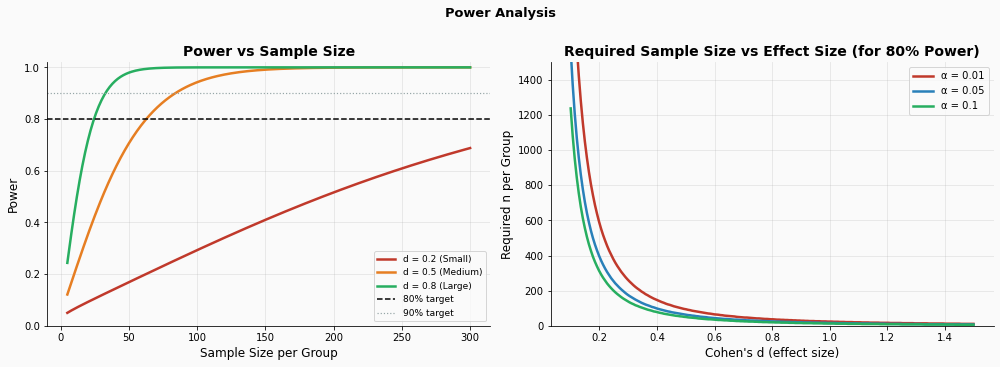

In [22]:
# ── Power curves: power vs sample size ────────────────────────
effect_sizes = [0.2, 0.5, 0.8]
n_range = np.arange(5, 301)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: power vs n for different effect sizes
for d_val, color in zip(effect_sizes, [RED, ORANGE, GREEN]):
    powers = [compute_power(d_val, n) for n in n_range]
    axes[0].plot(n_range, powers, color=color, linewidth=2.5,
                 label=f'd = {d_val} ({["Small","Medium","Large"][[0.2,0.5,0.8].index(d_val)]})')

axes[0].axhline(0.80, color='black', linestyle='--', linewidth=1.5, label='80% target')
axes[0].axhline(0.90, color=GREY,   linestyle=':',  linewidth=1.2, label='90% target')
axes[0].set_xlabel('Sample Size per Group'); axes[0].set_ylabel('Power')
axes[0].set_title('Power vs Sample Size'); axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1.02)

# Plot 2: required n vs effect size for different alpha
d_range = np.linspace(0.1, 1.5, 200)
for a_val, color in zip([0.01, 0.05, 0.10], [RED, BLUE, GREEN]):
    ns = [required_n(d, alpha=a_val) for d in d_range]
    axes[1].plot(d_range, ns, color=color, linewidth=2.5,
                 label=f'α = {a_val}')

axes[1].set_xlabel("Cohen's d (effect size)"); axes[1].set_ylabel('Required n per Group')
axes[1].set_title('Required Sample Size vs Effect Size (for 80% Power)')
axes[1].legend(fontsize=10); axes[1].set_ylim(0, 1500)

plt.suptitle('Power Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

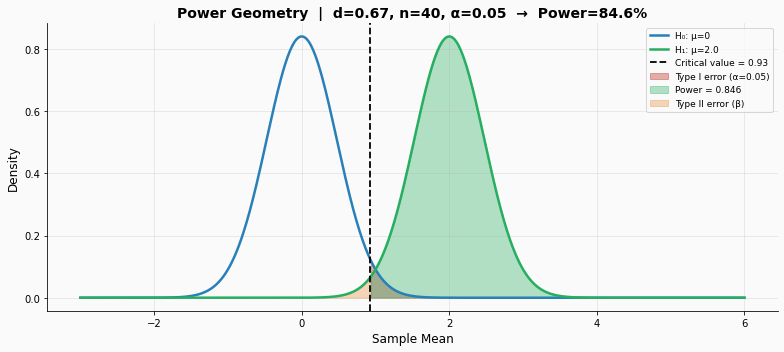

In [23]:
# ── Visualise power geometrically ─────────────────────────────
mu_0 = 0; mu_1 = 2.0; sigma = 3; n_geo = 40
alpha_geo = 0.05
se_geo = sigma / np.sqrt(n_geo)
z_crit = norm.ppf(1 - alpha_geo/2) * se_geo

x = np.linspace(-3, 6, 600)
y0 = norm.pdf(x, mu_0, se_geo)
y1 = norm.pdf(x, mu_1, se_geo)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x, y0, color=BLUE,  linewidth=2.5, label=f'H₀: μ={mu_0}')
ax.plot(x, y1, color=GREEN, linewidth=2.5, label=f'H₁: μ={mu_1}')

# Type I error (alpha)
x_t1 = x[x >= z_crit]
ax.fill_between(x_t1, norm.pdf(x_t1, mu_0, se_geo), alpha=0.4, color=RED,
                label=f'Type I error (α={alpha_geo})')

# Power
x_pw = x[x >= z_crit]
ax.fill_between(x_pw, norm.pdf(x_pw, mu_1, se_geo), alpha=0.35, color=GREEN,
                label=f'Power = {compute_power(mu_1/sigma, n_geo, alpha_geo):.3f}')

# Type II (beta)
x_t2 = x[x < z_crit]
ax.fill_between(x_t2, norm.pdf(x_t2, mu_1, se_geo), alpha=0.3, color=ORANGE,
                label='Type II error (β)')

ax.axvline(z_crit, color='black', linestyle='--', linewidth=1.8,
           label=f'Critical value = {z_crit:.2f}')

d_geo = mu_1 / sigma
ax.set_title(f'Power Geometry  |  d={d_geo:.2f}, n={n_geo}, α={alpha_geo}  '
             f'→  Power={compute_power(d_geo, n_geo, alpha_geo)*100:.1f}%')
ax.set_xlabel('Sample Mean'); ax.set_ylabel('Density')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout(); plt.show()

In [24]:
# ── Summary table: required n for various scenarios ───────────
print("Required sample size per group (α=0.05, power=0.80)")
print("=" * 55)
print(f"{'Effect size':<18} {'d':>6} {'n (per group)':>14} {'Total n':>9}")
print("-" * 55)
scenarios = [
    ('Small',  0.2),
    ('Medium', 0.5),
    ('Large',  0.8),
    ('Very large', 1.2),
]
for label, d_s in scenarios:
    n_s = required_n(d_s)
    print(f"{label:<18} {d_s:>6.1f} {n_s:>14} {2*n_s:>9}")

print()
print("Rule of thumb: halving the effect size quadruples the required n.")

Required sample size per group (α=0.05, power=0.80)
Effect size             d  n (per group)   Total n
-------------------------------------------------------
Small                 0.2            393       786
Medium                0.5             63       126
Large                 0.8             25        50
Very large            1.2             11        22

Rule of thumb: halving the effect size quadruples the required n.


---
## 🎯 Summary — The Key Ideas

| Concept | One-line Summary |
|---------|-----------------|
| **Hypothesis Testing** | Assume H₀, measure surprise, decide whether data is too extreme to be coincidence |
| **P-Value** | P(data this extreme \| H₀ true) — not the probability H₀ is true |
| **Significance Level α** | Your pre-set tolerance for false positives; 0.05 is convention, not magic |
| **Distributions** | Different processes have different shapes of randomness |
| **CLT** | Sample means always become Normal regardless of the population — the miracle of statistics |
| **Confidence Intervals** | A procedure that captures the true parameter 95% of the time across repeated studies |
| **Power** | Probability of detecting a real effect; needs large n, large effect, or lenient α |

### 🔗 Common Pitfalls
- p < 0.05 ≠ practically important (a tiny effect with huge n can be "significant")
- p > 0.05 ≠ no effect (may just be underpowered)
- 95% CI does NOT mean "95% probability the true mean is in this interval"
- Always do power analysis **before** collecting data, not after

---
*Notebook built with NumPy, SciPy, Matplotlib, and Pandas.*
